In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [35]:
deep = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/ELG/alltiles_ELGzinfo.fits'))
print(len(deep), len(np.unique(deep['TARGETID'])))

mask = deep['subset']=='deep'
print(np.sum(mask))
mask &= deep['TARGETS']=='ELG'
print(np.sum(mask))

deep = deep[mask]
print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove FIBERSTATUS!=0 fibers
mask = deep['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove "no data" fibers
mask = deep['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth for the deep coadd
min_depth = 4000.
mask = deep['R_DEPTH_EBVAIR']>min_depth
print(np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

print(len(deep), len(np.unique(deep['TARGETID'])))

deep.rename_columns(['B_DEPTH', 'R_DEPTH', 'Z_DEPTH', 'B_DEPTH_EBVAIR', 'R_DEPTH_EBVAIR', 'Z_DEPTH_EBVAIR'],
    ['B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep'])

179361 26051
27012
20382
20382 20382
FIBERSTATUS 16870 3512 0.17230890000981258
No data 16870 0 0.0
9510 7360 0.5637225844694724
9510 9510


## Select FDR ELGs

In [36]:
elg_sv = deep['SV1_DESI_TARGET'] & 2**1>0
elg_gtot = deep['SV1_DESI_TARGET'] & 2**10>0
elg_gfib = deep['SV1_DESI_TARGET'] & 2**11>0

deep = deep[elg_gtot]

In [37]:
zbest = Table(fitsio.read('/global/cfs/cdirs/desi/survey/catalogs/SV1/redshift_comps/blanc/v2/ELG/alltiles_ELGzinfo_1exp.fits'))
print(len(zbest), len(np.unique(zbest['TARGETID'])))

mask = np.in1d(zbest['TARGETID'], deep['TARGETID'])
mask &= np.in1d(zbest['TILEID'], np.unique(deep['TILEID']))
zbest = zbest[mask]
print(len(zbest), len(np.unique(zbest['TARGETID'])))

zbest = join(zbest, deep[['TARGETID', 'B_DEPTH_deep', 'R_DEPTH_deep', 'Z_DEPTH_deep', 'B_DEPTH_EBVAIR_deep', 'R_DEPTH_EBVAIR_deep', 'Z_DEPTH_EBVAIR_deep']], keys='TARGETID')

tileid_list = np.unique(zbest['TILEID'])

372447 26051
58176 3330


In [38]:
zbest[:1]

TARGETID,CHI2,COEFF [10],Z,ZERR,ZWARN,NPIXELS,SPECTYPE,SUBTYPE,NCOEFF,DELTACHI2,NUMEXP,NUMTILE,PETAL_LOC,DEVICE_LOC,LOCATION,FIBER,FIBERSTATUS,TARGET_RA,TARGET_DEC,PMRA,PMDEC,REF_EPOCH,LAMBDA_REF,FA_TARGET,FA_TYPE,OBJTYPE,FIBERASSIGN_X,FIBERASSIGN_Y,NUMTARGET,PRIORITY,SUBPRIORITY,OBSCONDITIONS,MORPHTYPE,FLUX_G,FLUX_R,FLUX_Z,FLUX_IVAR_G,FLUX_IVAR_R,FLUX_IVAR_Z,REF_ID,REF_CAT,GAIA_PHOT_G_MEAN_MAG,GAIA_PHOT_BP_MEAN_MAG,GAIA_PHOT_RP_MEAN_MAG,PARALLAX,EBV,FLUX_W1,FLUX_W2,FIBERFLUX_G,FIBERFLUX_R,FIBERFLUX_Z,FIBERTOTFLUX_G,FIBERTOTFLUX_R,FIBERTOTFLUX_Z,MASKBITS,SERSIC,SHAPE_R,SHAPE_E1,SHAPE_E2,PHOTSYS,SV1_DESI_TARGET,SV1_BGS_TARGET,SV1_MWS_TARGET,PRIORITY_INIT,NUMOBS_INIT,RELEASE,BRICKID,BRICKNAME,BRICK_OBJID,BLOBDIST,FIBERFLUX_IVAR_G,FIBERFLUX_IVAR_R,FIBERFLUX_IVAR_Z,DESI_TARGET,BGS_TARGET,MWS_TARGET,HPXPIXEL,NUM_ITER,FIBER_X,FIBER_Y,DELTA_X,DELTA_Y,FIBER_RA,FIBER_DEC,NIGHT,EXPID,MJD,TILEID,ELGTSNR,BGSTSNR,LRGTSNR,QSOTSNR,elgqso_weight,FIELD,TARGETS,SPECMODEL_SKY_RMAG_AB,HASGFA,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,Z_deep,ZWARN_deep,DELTACHI2_deep,B_DEPTH_deep,R_DEPTH_deep,Z_DEPTH_deep,B_DEPTH_EBVAIR_deep,R_DEPTH_EBVAIR_deep,Z_DEPTH_EBVAIR_deep
int64,float64,float64,float64,float64,int64,int64,str6,str20,int64,float64,int32,int32,int16,int32,int64,int32,int32,float64,float64,float32,float32,float32,float32,int64,uint8,str3,float32,float32,int16,int32,float64,int32,str4,float32,float32,float32,float32,float32,float32,int64,str2,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int16,float32,float32,float32,float32,str1,int64,int64,int64,int64,int64,int32,int32,str8,int32,float32,float32,float32,float32,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,int32,int32,float64,int32,float64,float64,float64,float64,float64,str10,str7,float32,bool,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,int64,float64,float64,float64,float64,float64,float64,float64
39627640553868904,9291.050867691636,149.18483041968554 .. 1.1323908765146895,1.4753666176608158,0.00015203111823524495,0,7843,GALAXY,,10,45.321022883057594,0,1,1,464,1464,524,0,35.746675241066676,-5.8999094331945825,0.0,0.0,2020.9487,5400.0,1374389536002,1,TGT,177.04205,-353.9224,0,3000,0.9570839083966932,3,DEV,1.0882385,1.5514032,3.8196244,310.81827,215.13818,19.531353,0,,0.0,0.0,0.0,0.0,0.026,10.238676,9.94459,0.15262029,0.21757694,0.5356842,0.15270323,0.21766777,0.535752,0,4.0,4.6535163,0.40477824,-0.105699725,S,1374389536002,0,0,3000,1,0,0,,0,0.0,0.0,0.0,0.0,0,0,0,0,2,177.001,-353.857,0.008,-0.006,35.74664468278833,-5.899930673671516,20201216,68284,59200.14312098,80606,960.9117720127106,16964.7177734375,93.12626123428345,122.04262351989746,1.0,XMM-LSS,ELG,21.390554,True,1500.3,1129.5,976.4,1167.6627,967.3597,895.428,1073741823,1073741823,1073741823,1073741823,1073741823,1073741823,4198,800,136,10,8,4060,201,10,131,36.448,-4.501,900.0,59200.145,1.257425,0.08022895,100.23187,92.341225,1.050341,0.89041924,20.955372,0.6296618,0.4480651,0.6613596,9.916743,6.556842,0.114,0.9316542,1.4756226857979526,0,119.63786733150482,9100.300079345703,7745.799865722656,7717.0001220703125,7068.034027099609,6628.393005371094,7074.704650878906


In [39]:
t = Table()
_, idx = np.unique(zbest['TARGETID'], return_index=True)
t['TILEID'], t['count_unique'] = np.unique(zbest['TILEID'][idx], return_counts=True)
t1 = Table()
t1['TILEID'], t1['count_repeat'] = np.unique(zbest['TILEID'], return_counts=True)
t = join(t, t1)
t['ratio'] = t['count_repeat']/t['count_unique']
t

TILEID,count_unique,count_repeat,ratio
int32,int64,int64,float64
80606,1257,14988,11.9236276849642
80608,1152,30462,26.442708333333332
80610,921,12726,13.817589576547231


80606 False 12


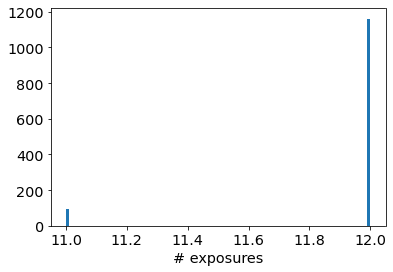

80608 False 27


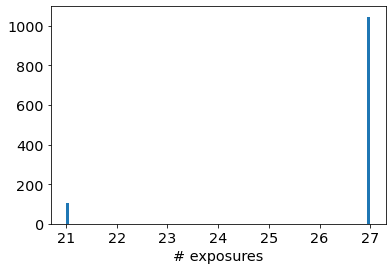

80610 False 14


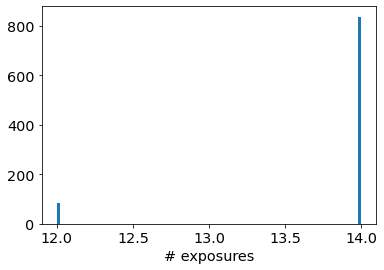

In [40]:
for tileid in tileid_list:
    mask = zbest['TILEID']==tileid
    t = Table()
    t['TARGETID'], t['count'] = np.unique(zbest['TARGETID'][mask], return_counts=True)
    print(tileid, np.all(t['count']== np.max(t['count'][0])), np.max(t['count'][0]))
    if not np.all(t['count']==t['count'][0]):
        plt.hist(t['count'], 100)
        plt.xlabel('# exposures')
        plt.show()

In [41]:
# stats = Table.read('/global/cfs/cdirs/desi/survey/observations/SV1/sv1-exposures.fits')
stats = Table.read('/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/sv1-exposures_20210210.fits')
print(len(stats))

mask = np.in1d(stats['EXPID'], np.unique(zbest['EXPID']))
stats = stats[mask]
print(len(stats))

stats['fail_frac_elg'] = -1.
stats['fail_n_elg'] = -1.

stats['deltachi2_ratio'] = -1.

mask_fiber = (zbest['FIBERSTATUS']==0) & (zbest['ZWARN'] & 2**9==0)

fail_threshold = 0.0033
mask_fail = np.abs((zbest['Z'] - zbest['Z_deep'])/(1 + zbest['Z_deep'])) > fail_threshold

for tileid in tileid_list:
    
    # print('Tile {}'.format(tileid))
        
    expid_list = np.array(np.unique(zbest['EXPID']))


    for expid in expid_list:
        
        stats_index = np.where(stats['EXPID']==expid)[0][0]
        
        mask_exp = mask_fiber & (zbest['EXPID']==expid)
        mask_exp_fail = mask_exp & mask_fail

        stats['fail_frac_elg'][stats_index] = np.sum(mask_exp_fail) / np.sum(mask_exp)
        stats['fail_n_elg'][stats_index] = np.sum(mask_exp_fail)
        
        mask_deltachi2 = zbest['DELTACHI2_deep']>100. # quality cut
        stats['deltachi2_ratio'][stats_index] = np.median((zbest['DELTACHI2']/(zbest['DELTACHI2_deep']/zbest['R_DEPTH_EBVAIR_deep']*1000))[mask_exp & mask_deltachi2])

974
53


In [42]:
# stats.write('/global/cscratch1/sd/rongpu/desi/sv1/single_exp_coadd_blanc/lrg_redshift_efficiency_new.fits')

In [43]:
stats[:1]

NIGHT,EXPID,FIELD,TARGETS,OBSCONDITIONS,EBV,SPECMODEL_SKY_GMAG_AB,SPECMODEL_SKY_RMAG_AB,GFA_ORIGIN,B_DEPTH,R_DEPTH,Z_DEPTH,B_DEPTH_EBVAIR,R_DEPTH_EBVAIR,Z_DEPTH_EBVAIR,BITPSFFN,BITFRAMEFN,BITSKYFN,BITSFRAMEFN,BITFLUXCALIBFN,BITCFRAMEFN,TGT,SKY,STD,WD,LRG,ELG,QSO,BGS,MWS,TILEID,TILERA,TILEDEC,EXPTIME,MJDOBS,GFA_AIRMASS,GFA_MOON_ILLUMINATION,GFA_MOON_ZD_DEG,GFA_MOON_SEP_DEG,GFA_TRANSPARENCY,GFA_FWHM_ASEC,GFA_SKY_MAG_AB,GFA_FIBER_FRACFLUX,GFA_FIBER_FRACFLUX_ELG,GFA_TRANSPFRAC,GFA_MAXCONTRAST,GFA_MINCONTRAST,GFA_KTERM,GFA_RADPROF_FWHM_ASEC,EPHEM_NOON,EPHEM_DUSK,EPHEM_DAWN,EPHEM_BRIGHTDUSK,EPHEM_BRIGHTDAWN,EPHEM_BRIGHTDUSK_LST,EPHEM_BRIGHTDAWN_LST,EPHEM_MOONRISE,EPHEM_MOONSET,EPHEM_MOON_ILLUM_FRAC,EPHEM_NEAREST_FULL_MOON,fail_frac_elg,fail_n_elg,deltachi2_ratio
int64,int64,bytes30,bytes16,int64,float32,float32,float32,bytes13,float32,float32,float32,float32,float32,float32,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,int64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
20201214,67733,XMM-LSS,ELG,1,0.026,22.425554,21.355791,matched_coadd,117.0,108.9,122.8,86.5628,90.97077,111.01914,1073741823,1073741823,1073741823,1073741823,0,0,4198,800,136,10,8,4060,201,10,131,80606,36.448,-4.501,900.0,59198.246,1.3984113,0.004661874,154.09523,118.24671,0.9449996,2.1302416,19.167242,0.21276562,0.18159902,0.20106342,6.5848656,3.4927726,0.114,2.1138735,59197.791666666664,59198.066745730626,59198.54668876452,59198.05982057322,59198.553616188605,-5.896143626986145,172.35701092094754,59197.59470830986,59198.02745986081,0.005432771706774475,14.852906347514363,0.5124584717607974,617.0,0.11423847206992185


In [44]:
# mask = stats['fail_frac_lrg_sv']!=-1
# print(np.sum(~mask))
# stats = stats[mask]

__Full depth range__

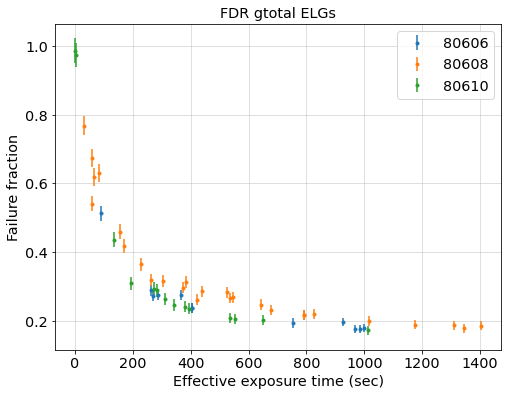

In [46]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = stats['TILEID']==tileid
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], stats['fail_frac_elg'][mask], 
                 yerr=1/np.sqrt(stats['fail_n_elg'][mask])*stats['fail_frac_elg'][mask],
                 fmt='.', label=tileid)
plt.xlabel('Effective exposure time (sec)')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('FDR gtotal ELGs')
plt.show()

__Only exposures with R_DEPTH_EBVAIR>250__

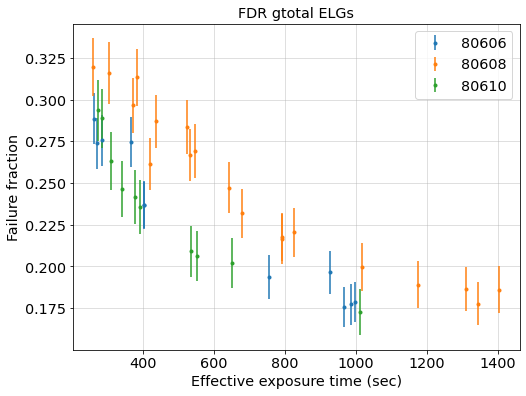

In [48]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    plt.errorbar((stats['R_DEPTH_EBVAIR'])[mask], stats['fail_frac_elg'][mask], 
                 yerr=1/np.sqrt(stats['fail_n_elg'][mask])*stats['fail_frac_elg'][mask],
                 fmt='.', label=tileid)
plt.xlabel('Effective exposure time (sec)')
plt.ylabel('Failure fraction')
plt.grid(alpha=0.5)
plt.legend(loc='upper right')
plt.title('FDR gtotal ELGs')
plt.show()

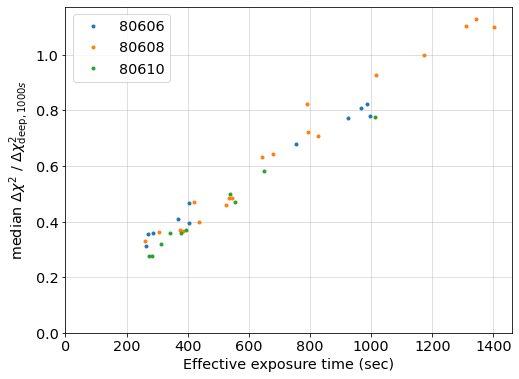

In [49]:
plt.figure(figsize=(8, 6))
for tileid in tileid_list:
    mask = (stats['TILEID']==tileid) & (stats['R_DEPTH_EBVAIR']>250)
    plt.plot((stats['R_DEPTH_EBVAIR'])[mask], stats['deltachi2_ratio'][mask], '.', label=tileid)
plt.xlabel('Effective exposure time (sec)')
plt.ylabel('median $\Delta\chi^2 \ / \ \Delta\chi_{\mathrm{deep},1000s}^2$')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.grid(alpha=0.5)
plt.legend(loc='upper left')
plt.show()